# Experiment Runner Notebook
**Multi-Aspect Sentiment Analysis - Ablation Studies & Baseline Comparisons**

Loads shared class definitions from `06_full_model_development.ipynb` via `%run`
(definition-only mode - no data loading or training triggered).

| Section | Contents |
|---|---|
| **1. Setup & Config** | Load `config.yaml`, output paths, device |
| **2. Load Shared Definitions** | `%run` notebook 06 (classes only) |
| **3. Baseline Models** | `PlainRoBERTa`, `DistilBERTBaseline`, `BERTBaseline`, `TFIDFSVMBaseline` |
| **4. Experiment Configs** | A1-A5, A7 ablations + B1–B4 baselines |
| **5. Experiment Engine** | `ExperimentTrainer`, `run_dl_experiment`, `run_tfidf_svm`, `run_experiments` |
| **6. Run Experiments** | Interactive cells to run any subset |
| **7. Results Analysis** | Tables, bar charts, MSR chart |


---
## Section 1 - Setup & Configuration
---

In [2]:
# ─────────────────────────────────────────────────────────────────────
# Imports & paths
#
# Standard imports shared across all cells.
# NOTEBOOK_DIR  - the folder this notebook lives in
# ML_ROOT       - ml-research/ root (two levels up from the notebook)
# CONFIG_PATH   - configs/config.yaml (loaded as BASE_CONFIG below)
# NB06_PATH     - path to 06_full_model_development.ipynb (used by %run in Section 2)
# RESULTS_DIR   - outputs/experiments/  (same folder as CLI experiment_runner)
# ALL_RESULTS_PATH - the cumulative results file written after every experiment
# ─────────────────────────────────────────────────────────────────────
import os, sys, json, time, copy, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import yaml

import torch
import torch.nn as nn
from transformers import (
    RobertaTokenizer, BertTokenizer, DistilBertTokenizer,
    RobertaModel, BertModel, DistilBertModel,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    precision_recall_fscore_support
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── Resolve paths ────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
ML_ROOT      = NOTEBOOK_DIR.parent.parent   # ml-research/
CONFIG_PATH  = ML_ROOT / 'configs' / 'config.yaml'
NB06_PATH    = NOTEBOOK_DIR.parent / '02_model_development' /'06_full_model_development.ipynb'

# ── Load base config from YAML ───────────────────────────────────────────────
# BASE_CONFIG is the starting point for every experiment.
# Each ablation/baseline function deep-copies this dict and modifies only
# the settings it wants to change — everything else stays the same.
with open(CONFIG_PATH, 'r') as f:
    BASE_CONFIG = yaml.safe_load(f)

# Convert relative data paths to absolute so the notebook works from any CWD
for key in ('train_path', 'val_path', 'test_path'):
    BASE_CONFIG['data'][key] = str(ML_ROOT / BASE_CONFIG['data'][key])

# Always enable MSR evaluation at baseline config level
BASE_CONFIG.setdefault('experiment', {}).setdefault('evaluate_msr', True)

# ── Output directory ─────────────────────────────────────────────────────────
RESULTS_DIR      = ML_ROOT / 'outputs' / 'experiments'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ALL_RESULTS_PATH = RESULTS_DIR / 'all_results.json'

DEVICE = torch.device(BASE_CONFIG['hardware']['device'] if torch.cuda.is_available() else 'cpu')

print(f'Config       : {CONFIG_PATH}')
print(f'Results dir  : {RESULTS_DIR}')
print(f'Results file : {ALL_RESULTS_PATH}')
print(f'Device       : {DEVICE}')
print(f'Aspects      : {BASE_CONFIG["aspects"]["names"]}')


Config       : c:\Users\lucif\Desktop\Clearview\ml-research\configs\config.yaml
Results dir  : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments
Results file : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json
Device       : cuda
Aspects      : ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']


---
## Section 2 - Load Shared Definitions from Notebook 06

Sets `builtins._NB_RUN_PIPELINE = False` before `%run` so that all execution
cells in `06_full_model_development.ipynb` are skipped - only class/function
definitions are loaded into this notebook's namespace.

---


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# How this works:
#
# 1. write  builtins._NB_RUN_PIPELINE = False  on the shared Python
#    builtins module (visible to all code running in this process).
#
# 2. %run executes every cell in 06_full_model_development.ipynb.
#    The very first cell in 07 reads the flag:
#      RUN_PIPELINE = getattr(builtins, '_NB_RUN_PIPELINE', True)
#    Because setting it to False, RUN_PIPELINE becomes False in 07.
#
# 3. Every 'execution' cell in 06 is wrapped with `if RUN_PIPELINE:`,
#    so data loading, training, and plot cells are all SKIPPED.
#    But class/function definition cells have no guard, so they DO run.
#
# 4. After %run finishes, all classes (MultiAspectSentimentModel, losses,
#    data utils, metrics) are available in THIS notebook's namespace.
#
# 5. Then reset the flag to True to leave no side effects.
# ─────────────────────────────────────────────────────────────────────
import builtins
builtins._NB_RUN_PIPELINE = False   # Tell 06 to skip execution cells

print(f'Loading definitions from {NB06_PATH}...')
%run {NB06_PATH}

builtins._NB_RUN_PIPELINE = True    # Reset flag - leave no side effects

# Verify the most important classes were loaded correctly
assert 'MultiAspectSentimentModel' in dir(), 'MultiAspectSentimentModel not loaded!'
assert 'AspectSpecificLossManager'  in dir(), 'AspectSpecificLossManager not loaded!'
assert 'AspectSentimentEvaluator'   in dir(), 'AspectSentimentEvaluator not loaded!'
assert 'MixedSentimentEvaluator'    in dir(), 'MixedSentimentEvaluator not loaded!'
assert 'create_dataloaders'         in dir(), 'create_dataloaders not loaded!'
assert 'DependencyParser'           in dir(), 'DependencyParser not loaded!'
print('All shared definitions loaded successfully.')


Loading definitions from c:\Users\lucif\Desktop\Clearview\ml-research\notebooks\02_model_development\06_full_model_development.ipynb...
PyTorch  : 2.5.1+cu121
CUDA     : True  (NVIDIA GeForce RTX 4060 Laptop GPU)
RUN_PIPELINE = False  (definition-only mode — execution cells will be skipped)
Config loaded from : c:\Users\lucif\Desktop\Clearview\ml-research\configs\config.yaml
Output directory   : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1
  Checkpoint       : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\best_model.pt
  Results JSON     : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\test_results.json
  Error log CSV    : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\cosmetic_sentiment_v1\errors.csv
Device             : cuda
Aspects            : ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']
Starting: Defining class CosmeticReviewDataset...
Completed: Defining

---
## Section 3 - Baseline Models

---


In [10]:
class PlainRoBERTa(nn.Module):
    """RoBERTa + [CLS] token + shared head. No aspect awareness."""
    def __init__(self, roberta_model='roberta-base', num_classes=3, dropout=0.1):
        super().__init__()
        self.roberta    = RobertaModel.from_pretrained(roberta_model)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class DistilBERTBaseline(nn.Module):
    """DistilBERT-base-uncased + shared [CLS] head. Aspect-unaware."""
    def __init__(self, model_name='distilbert-base-uncased', num_classes=3, dropout=0.1):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class BERTBaseline(nn.Module):
    """BERT-base-uncased + shared [CLS] head. Aspect-unaware."""
    def __init__(self, model_name='bert-base-uncased', num_classes=3, dropout=0.1):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CrossEntropyLossWrapper:
    """Same interface as AspectSpecificLossManager — drop-in CE loss."""
    def __init__(self):
        self.criterion = nn.CrossEntropyLoss()
    def compute_loss(self, predictions, targets, aspect_ids, aspect_names):
        loss = self.criterion(predictions, targets)
        return loss, {'ce': loss.item(), 'total': loss.item()}


class TFIDFSVMBaseline:
    """TF-IDF + LinearSVC. One pipeline per aspect. No GPU."""
    def __init__(self, aspect_names, max_features=50000, ngram_range=(1, 2)):
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.svm import LinearSVC
        from sklearn.calibration import CalibratedClassifierCV
        from sklearn.pipeline import Pipeline
        self.aspect_names = aspect_names
        self.pipelines    = {}
        for asp in aspect_names:
            self.pipelines[asp] = Pipeline([
                ('tfidf', TfidfVectorizer(max_features=max_features,
                    ngram_range=ngram_range, sublinear_tf=True,
                    strip_accents='unicode', analyzer='word', min_df=2)),
                ('clf',  CalibratedClassifierCV(
                    LinearSVC(class_weight='balanced', max_iter=2000, C=1.0))),
            ])
    def fit(self, df, label_map):
        for asp in self.aspect_names:
            mask = df[asp].notna()
            if mask.sum() == 0: continue
            X = df.loc[mask, 'data'].astype(str).tolist()
            y = df.loc[mask, asp].map(lambda v: label_map.get(str(v).lower(), -1)).tolist()
            valid = [(xi, yi) for xi, yi in zip(X, y) if yi != -1]
            if not valid: continue
            X_v, y_v = zip(*valid)
            print(f'  Fitting SVM for {asp}: {len(X_v)} samples')
            self.pipelines[asp].fit(X_v, y_v)
        print('TF-IDF + SVM training complete.')
    def predict(self, texts, aspect):       return self.pipelines[aspect].predict(texts)
    def predict_proba(self, texts, aspect): return self.pipelines[aspect].predict_proba(texts)
    def save(self, save_path):
        import joblib, os as _os
        _os.makedirs(save_path, exist_ok=True)
        for asp, pipe in self.pipelines.items():
            joblib.dump(pipe, _os.path.join(save_path, f'svm_{asp}.pkl'))
        print(f'SVM models saved to {save_path}')


def create_baseline(name, config):
    nc, dr = config['model']['num_classes'], config['model']['dropout']
    if name == 'plain_roberta':
        m = PlainRoBERTa(config['model']['roberta_model'], nc, dr)
    elif name == 'distilbert_base':
        m = DistilBERTBaseline('distilbert-base-uncased', nc, dr)
    elif name == 'bert_base':
        m = BERTBaseline('bert-base-uncased', nc, dr)
    elif name == 'tfidf_svm':
        return TFIDFSVMBaseline(config['aspects']['names'])
    else:
        raise ValueError(f'Unknown baseline: {name}')
    print(f'[Baseline] {name}: {m.get_num_parameters():,} params')
    return m


---
## Section 4 - Ablations studies

---



In [ ]:
# ─────────────────────────────────────────────────────────────────────
# validate_ablation()
#
# A safety check run before each experiment starts.
# Compares the new experiment config against the full model config (A1).
#   - If they are IDENTICAL (same architecture, data, hyperparams), it prints
#     a note saying results will be reused (no need to re-train).
#   - If specific keys were supposed to change but didn't, it raises a warning
#     so you catch accidental no-op ablations before wasting GPU time.
# The comparison ignores experiment.name and evaluate_msr (those always differ).
# ─────────────────────────────────────────────────────────────────────
def validate_ablation(exp_id, modified, base, keys=None):
    def _canonical(cfg):
        # Strip fields that always differ between experiments to
        # compare only the meaningful architectural/data/hyperparameter settings
        c = copy.deepcopy(cfg)
        c.get('experiment', {}).pop('name', None)
        c.get('experiment', {}).pop('evaluate_msr', None)
        return json.dumps(c, sort_keys=True)
    def _get(d, k):
        # Navigate nested dict using dotted key e.g. 'data.train_path'
        for p in k.split('.'): d = d.get(p, {})
        return d
    if _canonical(modified) == _canonical(base) and exp_id != 'A1_full_model':
        print(f'[NOTE] {exp_id} is identical to the Full Model — results will be reused.')
        return
    if keys:
        for key in keys:
            if _get(modified, key) == _get(base, key):
                warnings.warn(f'[WARN] {exp_id}: key {key} identical to base_config — may be unintended.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Ablation config generators
#
# Each function returns a list of (experiment_id, description, config) tuples.
# The config is a deep copy of BASE_CONFIG with ONLY the relevant settings changed.
# This ensures each experiment differs from A1 in exactly one dimension.
#
# A1 — GCN on vs off
# A2 — Aspect-aware attention vs plain CLS pooling
# A3 — Loss function: Hybrid / Focal only / CB only / Dice only
# A4 — With LLM-augmented training data vs original training data
# A5 — Per-aspect classifier heads vs one shared head
# A7 — Hybrid loss weight fine-tuning (Focal+CB balance)
# ─────────────────────────────────────────────────────────────────────

def ablation_1_gcn(base):
    """A1: Does the Dependency GCN improve performance?
    Changes: use_dependency_gcn + use_dependency_parsing flags.
    Both variants run MSR (Mixed Sentiment Resolution) evaluation."""
    full = copy.deepcopy(base); full['experiment']['name'] = 'A1_full_model'; full['experiment']['evaluate_msr'] = True
    validate_ablation('A1_full_model', full, base)
    no = copy.deepcopy(base); no['model']['use_dependency_gcn'] = False
    no['data']['use_dependency_parsing'] = False; no['experiment']['name'] = 'A1_no_gcn'; no['experiment']['evaluate_msr'] = True
    return [('A1_full_model', 'Full model with GCN + MSR', full),
            ('A1_no_gcn',     'No GCN (attention only) + MSR', no)]


def ablation_2_aspect_attention(base):
    """A2: Does aspect-guided MHA outperform plain CLS pooling?
    Changes: use_aspect_attention flag."""
    att = copy.deepcopy(base); att['experiment']['name'] = 'A2_aspect_attention'; att['experiment']['evaluate_msr'] = True
    validate_ablation('A2_aspect_attention', att, base)
    cls = copy.deepcopy(base); cls['model']['use_aspect_attention'] = False
    cls['experiment']['name'] = 'A2_cls_pooling'; cls['experiment']['evaluate_msr'] = True
    return [('A2_aspect_attention', 'Aspect-guided MHA + MSR', att),
            ('A2_cls_pooling', 'CLS pooling (no attention) + MSR', cls)]


def ablation_3_loss_function(base):
    """A3: Which loss component contributes most to handling class imbalance?
    Changes: training.loss_weights (focal / cb / dice coefficients)."""
    def mk(name, w):
        # Deep copy ensures each variant has an independent config dict
        c = copy.deepcopy(base); c['training']['loss_weights'] = w; c['experiment']['name'] = name; return c
    return [
        ('A3_hybrid_loss', 'Hybrid Loss (Focal+CB+Dice)',  mk('A3_hybrid_loss',  {'focal':1.0,'cb':0.5,'dice':0.3})),
        ('A3_focal_only',  'Focal Loss only',             mk('A3_focal_only',   {'focal':1.0,'cb':0.0,'dice':0.0})),
        ('A3_cb_only',     'Class-Balanced Loss only',    mk('A3_cb_only',      {'focal':0.0,'cb':1.0,'dice':0.0})),
        ('A3_dice_only',   'Dice Loss only',              mk('A3_dice_only',    {'focal':0.0,'cb':0.0,'dice':1.0})),
    ]


def ablation_4_augmentation(base):
    """A4: Does LLM-generated synthetic data improve performance?
    Changes: data.train_path (augmented vs original split)."""
    aug = copy.deepcopy(base)
    aug['data']['train_path'] = str(ML_ROOT / 'data/splits/train_augmented.csv')
    aug['experiment']['name'] = 'A4_with_augmentation'
    validate_ablation('A4_with_augmentation', aug, base, ['data.train_path'])
    no = copy.deepcopy(base)
    no['data']['train_path']  = str(ML_ROOT / 'data/splits/train.csv')
    no['experiment']['name']  = 'A4_no_augmentation'
    return [('A4_with_augmentation', 'With LLM augmentation', aug),
            ('A4_no_augmentation',   'Without augmentation',  no)]


def ablation_5_classifier_head(base):
    """A5: Do 7 aspect-specific heads outperform one shared head?
    Changes: model.use_shared_classifier flag."""
    asp = copy.deepcopy(base); asp['model']['use_shared_classifier'] = False
    asp['experiment']['name'] = 'A5_aspect_specific_heads'; asp['experiment']['evaluate_msr'] = True
    validate_ablation('A5_aspect_specific_heads', asp, base)
    sh = copy.deepcopy(base); sh['model']['use_shared_classifier'] = True
    sh['experiment']['name'] = 'A5_shared_head'; sh['experiment']['evaluate_msr'] = True
    return [('A5_aspect_specific_heads', '7 aspect-specific heads + MSR', asp),
            ('A5_shared_head',           'Single shared head + MSR',      sh)]

def ablation_7_hybrid_weights(base):
    """A7: Fine-tune the CB weight in hybrid loss (no Dice in this sweep).
    Changes: training.loss_weights CB coefficient (0.5 vs 1.0)."""
    def mk(name, w):
        c = copy.deepcopy(base); c['training']['loss_weights'] = w; c['experiment']['name'] = name; return c
    c05 = mk('A7_hybrid_cb_05', {'focal':1.0,'cb':0.5,'dice':0.0})
    validate_ablation('A7_hybrid_cb_05', c05, base)
    return [('A7_hybrid_cb_05', 'Focal 1.0 + CB 0.5 + Dice 0.0', c05),
            ('A7_hybrid_cb_10', 'Focal 1.0 + CB 1.0 + Dice 0.0', mk('A7_hybrid_cb_10',{'focal':1.0,'cb':1.0,'dice':0.0}))]


def get_all_ablation_specs(base):
    """Returns all ablation (experiment_id, description, config) tuples."""
    s = []
    s.extend(ablation_1_gcn(base))
    s.extend(ablation_2_aspect_attention(base))
    s.extend(ablation_3_loss_function(base))
    s.extend(ablation_4_augmentation(base))
    s.extend(ablation_5_classifier_head(base))
    s.extend(ablation_7_hybrid_weights(base))
    return s

def get_all_baseline_specs(base):
    """Returns all baseline (experiment_id, description, config) tuples."""
    specs = []
    # B1-B3: transformer baselines (same architecture, different encoder)
    for btype, eid, desc, enc in [
        ('plain_roberta',   'B1_plain_roberta',   'Plain RoBERTa',            None),
        ('distilbert_base', 'B2_distilbert_base', 'DistilBERT-base-uncased',  'distilbert-base-uncased'),
        ('bert_base',       'B3_bert_base',        'BERT-base-uncased',        'bert-base-uncased'),
    ]:
        c = copy.deepcopy(base); c['experiment']['name'] = eid
        c['experiment']['evaluate_msr'] = True; c['_baseline_type'] = btype
        if enc: c['model']['roberta_model'] = enc
        specs.append((eid, desc, c))
    # B4: classical ML baseline (no GPU, no transformers)
    b4 = copy.deepcopy(base); b4['experiment']['name'] = 'B4_tfidf_svm'
    b4['experiment']['evaluate_msr'] = True; b4['_baseline_type'] = 'tfidf_svm'
    specs.append(('B4_tfidf_svm', 'Classical TF-IDF + LinearSVC', b4))
    return specs

def print_experiment_plan(base):
    """Print a human-readable list of all planned experiments."""
    abl = get_all_ablation_specs(base); bsl = get_all_baseline_specs(base)
    print('='*70); print('EXPERIMENT PLAN'); print('='*70)
    print('\n-- Baselines ' + '-'*57)
    for eid, desc, _ in bsl:  print(f'  [{eid}]  {desc}')
    print('\n-- Ablations ' + '-'*57)
    for eid, desc, _ in abl:  print(f'  [{eid}]  {desc}')
    print(f'\nTotal: {len(abl)+len(bsl)} experiments  (A6 removed — MSR in A1/A2/A5)')
    print('='*70)


---
## Section 5 - Experiment Engine
---


In [12]:
def empty_result(exp_id, desc):
    return {'experiment_id': exp_id, 'description': desc, 'status': 'pending',
            'error': None, 'duration_mins': None, 'overall': {},
            'per_aspect': {}, 'mixed_sentiment': {}}

def _ser(obj):
    if isinstance(obj, np.ndarray):              return obj.tolist()
    if isinstance(obj, (np.int64,  np.int32)):   return int(obj)
    if isinstance(obj, (np.float64,np.float32)): return float(obj)
    if isinstance(obj, dict):  return {k: _ser(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [_ser(x) for x in obj]
    return obj


class ExperimentTrainer:
    """Trains any nn.Module compatible with the shared forward signature."""
    def __init__(self, exp_id, config, model, loss_manager, tokenizer, results_dir):
        self.exp_id     = exp_id; self.config = config
        self.model      = model;  self.loss_manager = loss_manager
        self.results_dir = results_dir
        self.device = torch.device(config['hardware']['device'] if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        dep_parser = None
        if config['data'].get('use_dependency_parsing', False):
            dep_parser = DependencyParser('en_core_web_sm')
        self.train_loader, self.val_loader, self.test_loader = create_dataloaders(config, tokenizer, dep_parser)

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config['training']['learning_rate'],
            weight_decay=config['training']['weight_decay'])
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=config['training']['warmup_steps'],
            num_training_steps=len(self.train_loader)*config['training']['num_epochs'])
        self.use_amp = config['hardware'].get('mixed_precision', False) and torch.cuda.is_available()
        if self.use_amp:
            from torch.cuda.amp import GradScaler; self.scaler = GradScaler()

        self.evaluator    = AspectSentimentEvaluator(config['aspects']['names'])
        self.best_val_f1  = 0.0; self.best_epoch = 0; self.patience_ctr = 0
        self.patience     = config['training']['early_stopping_patience']

    def _forward(self, batch):
        iids = batch['input_ids'].to(self.device)
        amsk = batch['attention_mask'].to(self.device)
        aids = batch['aspect_ids'].to(self.device)
        ei   = None
        if self.config['model'].get('use_dependency_gcn', False):
            ei = [e.to(self.device) if e is not None else None for e in batch['edge_indices']]
        return self.model(iids, amsk, aids, ei)

    def train_epoch(self):
        self.model.train(); total_loss = 0
        an = self.config['aspects']['names']
        for batch in tqdm(self.train_loader, desc='Training', leave=False):
            lbl = batch['labels'].to(self.device)
            aid = batch['aspect_ids'].to(self.device)
            self.optimizer.zero_grad()
            if self.use_amp:
                from torch.cuda.amp import autocast
                with autocast():
                    p = self._forward(batch)
                    if isinstance(p, tuple): p = p[0]
                    loss, _ = self.loss_manager.compute_loss(p, lbl, aid, an)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.scaler.step(self.optimizer); self.scaler.update()
            else:
                p = self._forward(batch)
                if isinstance(p, tuple): p = p[0]
                loss, _ = self.loss_manager.compute_loss(p, lbl, aid, an)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.optimizer.step()
            self.scheduler.step(); total_loss += loss.item()
        return total_loss / max(len(self.train_loader), 1)

    def evaluate(self, loader):
        self.model.eval()
        all_preds, all_labels, all_aspects, all_probs = [], [], [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc='Evaluating', leave=False):
                p = self._forward(batch)
                if isinstance(p, tuple): p = p[0]
                probs = torch.softmax(p, dim=1).cpu().numpy()
                all_probs.extend(probs); all_preds.extend(np.argmax(probs, axis=1))
                all_labels.extend(batch['labels'].numpy())
                all_aspects.extend(batch['aspects'])
        yt = np.array(all_labels); yp = np.array(all_preds); yb = np.array(all_probs)
        asp_metrics = {}
        for asp in self.config['aspects']['names']:
            mask = np.array([a == asp for a in all_aspects])
            if mask.sum(): asp_metrics[asp] = self.evaluator.evaluate_aspect(yt[mask], yp[mask], asp, y_prob=yb[mask])
        ov = self.evaluator.evaluate_aspect(yt, yp, 'overall', y_prob=yb)
        return {'overall': ov, 'aspects': asp_metrics, 'preds': yp, 'labels': yt,
                'probs': yb, 'aspect_list': all_aspects}

    def train(self):
        print(f'\n[{self.exp_id}] Training for {self.config["training"]["num_epochs"]} epochs')
        t0 = time.time(); ckpt = self.results_dir / f'{self.exp_id}_best.pt'
        if ckpt.exists():
            print(f'  Checkpoint found — loading {ckpt.name}')
        else:
            for epoch in range(self.config['training']['num_epochs']):
                tl  = self.train_epoch()
                vr  = self.evaluate(self.val_loader)
                vf1 = vr['overall']['macro_f1']
                print(f'  Epoch {epoch+1:02d}: loss={tl:.4f}  val_f1={vf1:.4f}  patience={self.patience_ctr}/{self.patience}')
                if vf1 > self.best_val_f1:
                    self.best_val_f1 = vf1; self.best_epoch = epoch+1; self.patience_ctr = 0
                    torch.save({'model_state_dict': self.model.state_dict(), 'config': self.config,
                                'best_epoch': self.best_epoch, 'best_val_f1': vf1}, ckpt)
                    print(f'    Saved best (epoch={self.best_epoch}, val_f1={vf1:.4f})')
                else:
                    self.patience_ctr += 1
                    if self.patience_ctr >= self.patience:
                        print(f'  Early stopping at epoch {epoch+1}'); break
        if ckpt.exists():
            c = torch.load(ckpt, map_location=self.device, weights_only=False)
            self.model.load_state_dict(c['model_state_dict'])
            self.best_epoch = c.get('best_epoch', self.best_epoch)
            self.best_val_f1= c.get('best_val_f1', self.best_val_f1)
        test_m = self.evaluate(self.test_loader); dur = (time.time()-t0)/60
        print(f'  Done in {dur:.1f} min — test_macro_f1={test_m["overall"]["macro_f1"]:.4f}  best_epoch={self.best_epoch}')
        return test_m, dur


In [14]:
def run_msr_evaluation(exp_id, config, trainer):
    """Collect per-review predictions and compute MSR metrics."""
    print(f'  [{exp_id}] Running MSR evaluation...')
    review_true = {}; review_pred = {}
    trainer.model.eval()
    with torch.no_grad():
        for batch in tqdm(trainer.test_loader, desc='MSR pass', leave=False):
            iids = batch['input_ids'].to(trainer.device)
            amsk = batch['attention_mask'].to(trainer.device)
            aids = batch['aspect_ids'].to(trainer.device)
            ei   = None
            if config['model'].get('use_dependency_gcn', False):
                ei = [e.to(trainer.device) if e is not None else None for e in batch['edge_indices']]
            p = trainer.model(iids, amsk, aids, ei)
            if isinstance(p, tuple): p = p[0]
            cls = torch.argmax(p, dim=1).cpu().numpy()
            for i in range(len(cls)):
                rid = batch['review_ids'][i]; asp = batch['aspects'][i]
                review_true.setdefault(rid, {})[asp] = batch['labels'][i].item()
                review_pred.setdefault(rid, {})[asp] = int(cls[i])
    ev = MixedSentimentEvaluator(config['aspects']['names'])
    m  = ev.evaluate_mixed_sentiment_resolution(review_true, review_pred)
    return {'mixed_review_count': m.get('mixed_review_count',0),
            'mixed_review_accuracy': m.get('mixed_review_accuracy',0.0),
            'mixed_aspect_accuracy': m.get('mixed_aspect_accuracy',0.0),
            'mixed_prevalence': m.get('mixed_prevalence',0.0)}


def run_dl_experiment(exp_id, desc, config, results_dir, base_config):
    result = empty_result(exp_id, desc)
    torch.manual_seed(config['experiment']['seed'])
    np.random.seed(config['experiment']['seed'])
    try:
        enc = config['model']['roberta_model']
        if 'distilbert' in enc:                       tok = DistilBertTokenizer.from_pretrained(enc)
        elif 'bert' in enc and 'roberta' not in enc:  tok = BertTokenizer.from_pretrained(enc)
        else:                                          tok = RobertaTokenizer.from_pretrained(enc)

        if exp_id.startswith('B1_'):   model = create_baseline('plain_roberta', config)
        elif exp_id.startswith('B2_'): model = create_baseline('distilbert_base', config)
        elif exp_id.startswith('B3_'): model = create_baseline('bert_base', config)
        else:                          model = create_model(config)

        if config['training'].get('use_ce_loss', False):
            loss_mgr = CrossEntropyLossWrapper()
        else:
            counts   = compute_class_weights(config['data']['train_path'],
                           config['aspects']['names'], config['aspects']['label_map'])
            loss_mgr = AspectSpecificLossManager(counts, config['training'])

        trainer = ExperimentTrainer(exp_id, config, model, loss_mgr, tok, results_dir)
        test_m, dur = trainer.train()

        result.update({
            'status': 'done', 'duration_mins': round(dur, 2),
            'best_epoch': trainer.best_epoch, 'best_val_f1': round(trainer.best_val_f1, 6),
            'num_parameters': model.get_num_parameters(),
            'overall':    _ser(test_m['overall']),
            'per_aspect': _ser(test_m['aspects']),
        })
        if config.get('experiment', {}).get('evaluate_msr', False):
            result['mixed_sentiment'] = run_msr_evaluation(exp_id, config, trainer)
    except Exception:
        import traceback
        result['status'] = 'error'; result['error'] = traceback.format_exc()
        print(f'  [{exp_id}] FAILED:\n{result["error"]}')
    return result


def run_tfidf_svm(exp_id, desc, config, results_dir):
    t0 = time.time(); lmap = config['aspects']['label_map']; aspects = config['aspects']['names']
    train_df = pd.read_csv(config['data']['train_path'])
    test_df  = pd.read_csv(config['data']['test_path'])
    svm = TFIDFSVMBaseline(aspect_names=aspects)
    svm.fit(train_df, lmap)
    svm.save(str(results_dir / exp_id))

    ot, op, per_asp = [], [], {}
    for asp in aspects:
        mask = test_df[asp].notna()
        if mask.sum() == 0: continue
        X = test_df.loc[mask,'data'].astype(str).tolist()
        y = test_df.loc[mask, asp].map(lambda v: lmap.get(str(v).lower(),-1)).tolist()
        valid = [(xi,yi) for xi,yi in zip(X,y) if yi!=-1]
        if not valid: continue
        X_v, y_v = zip(*valid)
        yp = svm.predict(list(X_v), asp); y_v = list(y_v)
        pr, rc, f1, sup = precision_recall_fscore_support(y_v, yp, average=None, labels=[0,1,2], zero_division=0)
        per_asp[asp] = {
            'accuracy': float(accuracy_score(y_v, yp)),
            'macro_f1': float(f1_score(y_v, yp, average='macro', zero_division=0)),
            'weighted_f1': float(f1_score(y_v, yp, average='weighted', zero_division=0)),
            'mcc': float(matthews_corrcoef(y_v, yp)),
            'per_class_f1': [float(x) for x in f1],
            'per_class_precision': [float(x) for x in pr],
            'per_class_recall': [float(x) for x in rc],
            'support': [int(x) for x in sup],
        }
        ot.extend(y_v); op.extend(yp.tolist())
    overall = {'accuracy': float(accuracy_score(ot,op)),
               'macro_f1': float(f1_score(ot,op,average='macro',zero_division=0)),
               'weighted_f1': float(f1_score(ot,op,average='weighted',zero_division=0)),
               'mcc': float(matthews_corrcoef(ot,op))} if ot else {}
    dur = (time.time()-t0)/60
    print(f'  [{exp_id}] Done in {dur:.1f} min — macro_f1={overall.get("macro_f1",0):.4f}')

    mixed = {}
    if config.get('experiment',{}).get('evaluate_msr', False):
        try:
            rt, rp = {}, {}
            for asp in aspects:
                cm = test_df[asp].notna()
                sb = test_df.loc[cm].copy()
                yt_r = sb[asp].map(lambda v: lmap.get(str(v).lower(),-1)).tolist()
                yp_r = svm.predict(sb['data'].astype(str).tolist(), asp).tolist()
                for pos, rid in enumerate(sb.index):
                    if yt_r[pos]==-1: continue
                    rt.setdefault(rid,{})[asp]=int(yt_r[pos]); rp.setdefault(rid,{})[asp]=int(yp_r[pos])
            ev = MixedSentimentEvaluator(aspects)
            m  = ev.evaluate_mixed_sentiment_resolution(rt, rp)
            mixed = {'mixed_review_count': m.get('mixed_review_count',0),
                     'mixed_review_accuracy': m.get('mixed_review_accuracy',0.0),
                     'mixed_aspect_accuracy': m.get('mixed_aspect_accuracy',0.0),
                     'mixed_prevalence': m.get('mixed_prevalence',0.0)}
        except Exception as e: print(f'  [{exp_id}] MSR: {e}')
    return {'experiment_id':exp_id,'description':desc,'status':'done','error':None,
            'duration_mins':round(dur,2),'overall':overall,'per_aspect':per_asp,'mixed_sentiment':mixed}


def _check_isolation(exp_ids, all_specs):
    def _can(cfg):
        c=copy.deepcopy(cfg); c.get('experiment',{}).pop('name',None)
        c.get('experiment',{}).pop('evaluate_msr',None); return json.dumps(c,sort_keys=True)
    seen,issues={}, []
    for eid in exp_ids:
        if eid not in all_specs: continue
        _,_,cfg = all_specs[eid]; k=_can(cfg)
        if k in seen: issues.append(f'  WARNING: [{eid}] identical config to [{seen[k]}]')
        else: seen[k]=eid
    if issues: print('\n'+'!'*65+'\nDUPLICATES DETECTED:'); [print(i) for i in issues]; print('!'*65)



def run_eval_from_checkpoint(exp_id, desc, config, results_dir, base_config):
    """Load an existing .pt checkpoint and run test evaluation — no training."""
    result = empty_result(exp_id, desc)
    t0 = time.time()
    ckpt = results_dir / f'{exp_id}_best.pt'
    try:
        enc = config['model']['roberta_model']
        if 'distilbert' in enc:                       tok = DistilBertTokenizer.from_pretrained(enc)
        elif 'bert' in enc and 'roberta' not in enc:  tok = BertTokenizer.from_pretrained(enc)
        else:                                          tok = RobertaTokenizer.from_pretrained(enc)

        if exp_id.startswith('B1_'):   model = create_baseline('plain_roberta', config)
        elif exp_id.startswith('B2_'): model = create_baseline('distilbert_base', config)
        elif exp_id.startswith('B3_'): model = create_baseline('bert_base', config)
        else:                          model = create_model(config)

        if config['training'].get('use_ce_loss', False):
            loss_mgr = CrossEntropyLossWrapper()
        else:
            counts = compute_class_weights(config['data']['train_path'],
                         config['aspects']['names'], config['aspects']['label_map'])
            loss_mgr = AspectSpecificLossManager(counts, config['training'])

        trainer = ExperimentTrainer(exp_id, config, model, loss_mgr, tok, results_dir)
        c = torch.load(ckpt, map_location=trainer.device, weights_only=False)
        trainer.model.load_state_dict(c['model_state_dict'])
        trainer.best_epoch  = c.get('best_epoch', 0)
        trainer.best_val_f1 = c.get('best_val_f1', 0.0)
        print(f'  Loaded {ckpt.name}  (best_epoch={trainer.best_epoch}, val_f1={trainer.best_val_f1:.4f})')

        test_m = trainer.evaluate(trainer.test_loader)
        dur = (time.time() - t0) / 60
        print(f'  Done in {dur:.1f} min — test_macro_f1={test_m["overall"]["macro_f1"]:.4f}')

        result.update({
            'status': 'done', 'duration_mins': round(dur, 2),
            'best_epoch': trainer.best_epoch, 'best_val_f1': round(trainer.best_val_f1, 6),
            'num_parameters': model.get_num_parameters(),
            'overall':    _ser(test_m['overall']),
            'per_aspect': _ser(test_m['aspects']),
        })
        if config.get('experiment', {}).get('evaluate_msr', False):
            result['mixed_sentiment'] = run_msr_evaluation(exp_id, config, trainer)
    except Exception:
        import traceback
        result['status'] = 'error'; result['error'] = traceback.format_exc()
        print(f'  [{exp_id}] FAILED:{result["error"]}')
    return result


def run_experiments(exp_ids, base_config, results_dir):
    abl = {k:(k,d,c) for k,d,c in get_all_ablation_specs(base_config)}
    bsl = {k:(k,d,c) for k,d,c in get_all_baseline_specs(base_config)}
    all_specs = {**abl, **bsl}
    _check_isolation(exp_ids, all_specs)

    results = {}; out = results_dir/'all_results.json'
    if out.exists():
        try:
            with open(out) as f: results=json.load(f)
            print(f'Loaded {len(results)} existing results from {out}')
        except Exception as e: print(f'Could not load {out}: {e}')

    def _can(cfg):
        c=copy.deepcopy(cfg); c.get('experiment',{}).pop('name',None)
        c.get('experiment',{}).pop('evaluate_msr',None); return json.dumps(c,sort_keys=True)

    fmk = _can(all_specs['A1_full_model'][2]) if 'A1_full_model' in all_specs else None

    for eid in exp_ids:
        if eid not in all_specs: print(f'  Unknown: {eid}'); continue
        eid, desc, cfg = all_specs[eid]
        is_bl = bool(cfg.get('_baseline_type'))

        if fmk and eid!='A1_full_model' and not is_bl and _can(cfg)==fmk:
            print(f'\nSKIPPING [{eid}] — identical to A1_full_model')
            if 'A1_full_model' in results:
                results[eid]=copy.deepcopy(results['A1_full_model'])
                results[eid]['experiment_id']=eid; results[eid]['description']=desc
                for k in ['overall', 'per_aspect']:
                    if k in results[eid]:
                        if k == 'overall' and isinstance(results[eid][k], dict):
                            for mk in ['y_true', 'y_prob', 'roc_auc']: results[eid][k].pop(mk, None)
                        elif k == 'per_aspect' and isinstance(results[eid][k], dict):
                            for asp in results[eid][k].values():
                                if isinstance(asp, dict):
                                    for mk in ['y_true', 'y_prob', 'roc_auc']: asp.pop(mk, None)
            else:
                results[eid]=empty_result(eid,desc); results[eid]['status']='skipped (run A1 first)'
            with open(out,'w') as f: json.dump(results,f,indent=2)
            continue

        print(f'\n{"="*65}\nRunning: [{eid}]  {desc}\n{"="*65}')
        if cfg.get('_baseline_type')=='tfidf_svm':
            res = run_tfidf_svm(eid, desc, cfg, results_dir)
        elif (results_dir / f'{eid}_best.pt').exists():
            print(f'  Checkpoint found — running evaluation only (skipping training)')
            res = run_eval_from_checkpoint(eid, desc, cfg, results_dir, base_config)
        else:
            res = run_dl_experiment(eid, desc, cfg, results_dir, base_config)
        if eid != 'A1_full_model':
            for k in ['overall', 'per_aspect']:
                if k in res:
                    if k == 'overall' and isinstance(res[k], dict):
                        for mk in ['y_true', 'y_prob', 'roc_auc']: res[k].pop(mk, None)
                    elif k == 'per_aspect' and isinstance(res[k], dict):
                        for asp in res[k].values():
                            if isinstance(asp, dict):
                                for mk in ['y_true', 'y_prob', 'roc_auc']: asp.pop(mk, None)
        results[eid] = res
        with open(out,'w') as f: json.dump(results,f,indent=2)
        print(f'  Saved to {out}')

    return results


---
## Section 6 - Run Experiments
Each cell is independent. Run any single one or all of them.

> **How to use Section 6**
>
> - Run **`show-plan`** first to see all experiment IDs.
> - Run **`run-single`** to test one experiment before committing to a full run.
> - Run **`run-ablations`** or **`run-baselines`** to run groups independently.
> - Run **`run-all`** only when you are ready for the full experiment batch.
> - Each cell saves to `all_results.json` immediately - interrupted runs are resumable.

---


In [ ]:
# Print a summary of every experiment before running anything.
# Use this to confirm which experiments will run and in what order.
print_experiment_plan(BASE_CONFIG)


In [ ]:
# Run ONE experiment by its ID.
# Change 'A1_full_model' to any ID shown in the plan above.
# Results are saved to all_results.json immediately after it completes.
results = run_experiments(['A1_full_model'], BASE_CONFIG, RESULTS_DIR)


In [16]:
# Run ALL ablation experiments (A1–A5, A7).
# Experiments identical to A1_full_model are auto-skipped (results reused).
# Interrupted runs can be resumed — completed experiments are skipped.
ablation_ids = [s[0] for s in get_all_ablation_specs(BASE_CONFIG)]
results = run_experiments(ablation_ids, BASE_CONFIG, RESULTS_DIR)


[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.
[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DUPLICATES DETECTED:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Running: [A1_full_model]  Full model with GCN + MSR
  Checkpoint found — running evaluation only (skipping training)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Model] Created with 132,637,464 trainable parameters

[ClassWeights] Computing from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv


  Counting per aspect: 100%|██████████| 7/7 [00:00<00:00, 221.60it/s]


  stayingpower    : neg=  727  neu=  244  pos= 1076
  texture         : neg=  639  neu=  420  pos= 2563
  smell           : neg=  335  neu=  274  pos= 1668
  price           : neg=  201  neu=  218  pos= 2295
  colour          : neg=  499  neu=  428  pos= 4483
  shipping        : neg= 1216  neu=  267  pos= 2406
  packing         : neg=  236  neu=  177  pos= 2068
  Loss for [stayingpower    ]: ratio=     4.4  gamma=2.0  beta=0.999
  Loss for [texture         ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [smell           ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [price           ]: ratio=    11.4  gamma=2.5  beta=0.999
  Loss for [colour          ]: ratio=    10.5  gamma=2.5  beta=0.999
  Loss for [shipping        ]: ratio=     9.0  gamma=2.0  beta=0.999
  Loss for [packing         ]: ratio=    11.7  gamma=2.5  beta=0.999
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split 

...

[Loaders] test: 4465 samples → 280 batches
[Evaluator] Tracking 7 aspects: ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']
  Loaded A7_hybrid_cb_10_best.pt  (best_epoch=0, val_f1=0.0000)


  [stayingpower]  acc=0.8665  macro_f1=0.8122  mcc=0.7677  roc_auc=0.9486
    per-class F1 → neg=0.8683  neu=0.6596  pos=0.9087
  [texture]  acc=0.8962  macro_f1=0.7996  mcc=0.7487  roc_auc=0.9543
    per-class F1 → neg=0.8468  neu=0.6053  pos=0.9468
  [smell]  acc=0.9281  macro_f1=0.7653  mcc=0.7858  roc_auc=0.9587
    per-class F1 → neg=0.9048  neu=0.4286  pos=0.9625
  [price]  acc=0.9572  macro_f1=0.4956  mcc=0.2834  roc_auc=0.8977
    per-class F1 → neg=0.2222  neu=0.2857  pos=0.9790
  [colour]  acc=0.9150  macro_f1=0.7442  mcc=0.6950  roc_auc=0.9414
    per-class F1 → neg=0.7700  neu=0.5000  pos=0.9627
  [shipping]  acc=0.9167  macro_f1=0.7909  mcc=0.8382  roc_auc=0.9621
    per-class F1 → neg=0.9213  neu=0.4909  pos=0.9606
  [packing]  acc=0.9801  macro_f1=0.6269  mcc=0.8158  roc_auc=0.9782
    per-class F1 → neg=0.8889  neu=0.0000  pos=0.9918
  [overall]  acc=0.9203  macro_f1=0.7885  mcc=0.7813  roc_auc=0.9536
    per-class F1 → neg=0.8689  neu=0.5343  pos=0.9622
  Done in 2.7 m

[MSREvaluator] Tracking 7 aspects


  Scoring: 100%|██████████| 628/628 [00:00<00:00, 573986.25it/s]


[MSR] Review-level accuracy: 68.95%  |  Aspect-level accuracy: 87.66%
  Saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json


In [17]:
# Run ALL baselines (B1 PlainRoBERTa, B2 DistilBERT, B3 BERT, B4 TF-IDF+SVM).
# B4 uses sklearn (CPU only) — all others require GPU.
baseline_ids = [s[0] for s in get_all_baseline_specs(BASE_CONFIG)]
results = run_experiments(baseline_ids, BASE_CONFIG, RESULTS_DIR)


[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.
Loaded 14 existing results from c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json

Running: [B1_plain_roberta]  Plain RoBERTa [CLS] + CE loss
  Checkpoint found — running evaluation only (skipping training)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Baseline] plain_roberta: 124,647,939 params

[ClassWeights] Computing from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv


  Counting per aspect: 100%|██████████| 7/7 [00:00<00:00, 219.98it/s]


  stayingpower    : neg=  727  neu=  244  pos= 1076
  texture         : neg=  639  neu=  420  pos= 2563
  smell           : neg=  335  neu=  274  pos= 1668
  price           : neg=  201  neu=  218  pos= 2295
  colour          : neg=  499  neu=  428  pos= 4483
  shipping        : neg= 1216  neu=  267  pos= 2406
  packing         : neg=  236  neu=  177  pos= 2068
  Loss for [stayingpower    ]: ratio=     4.4  gamma=2.0  beta=0.999
  Loss for [texture         ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [smell           ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [price           ]: ratio=    11.4  gamma=2.5  beta=0.999
  Loss for [colour          ]: ratio=    10.5  gamma=2.5  beta=0.999
  Loss for [shipping        ]: ratio=     9.0  gamma=2.0  beta=0.999
  Loss for [packing         ]: ratio=    11.7  gamma=2.5  beta=0.999
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split 

...

  Scoring: 100%|██████████| 628/628 [00:00<00:00, 1232003.23it/s]


[MSR] Review-level accuracy: 0.00%  |  Aspect-level accuracy: 49.10%
  Saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json

Running: [B4_tfidf_svm]  Classical TF-IDF + LinearSVC
  Fitting SVM for stayingpower: 2047 samples
  Fitting SVM for texture: 3622 samples
  Fitting SVM for smell: 2277 samples
  Fitting SVM for price: 2714 samples
  Fitting SVM for colour: 5410 samples
  Fitting SVM for shipping: 3889 samples
  Fitting SVM for packing: 2481 samples
TF-IDF + SVM training complete.
SVM models saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\B4_tfidf_svm
  [B4_tfidf_svm] Done in 0.0 min — macro_f1=0.6971
[MSREvaluator] Tracking 7 aspects


  Scoring: 100%|██████████| 628/628 [00:00<?, ?it/s]

[MSR] Review-level accuracy: 56.05%  |  Aspect-level accuracy: 82.58%


  Saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json


In [ ]:
# Run EVERYTHING: baselines first, then ablations.
# Baselines run first so that the redundancy check for ablations
# can reuse A1_full_model results if any ablation is identical to it.
all_ids = (
    [s[0] for s in get_all_baseline_specs(BASE_CONFIG)] +
    [s[0] for s in get_all_ablation_specs(BASE_CONFIG)]
)
results = run_experiments(all_ids, BASE_CONFIG, RESULTS_DIR)


---
## Section 7 - Results Analysis
Load `all_results.json` and generate comparison tables and charts.

---

In [3]:
# Load the cumulative results file from disk.
# This works even after a kernel restart — you don't need to re-run any experiments.
with open(ALL_RESULTS_PATH) as f:
    results = json.load(f)
print(f'Loaded {len(results)} experiments from {ALL_RESULTS_PATH}\n')

# Build a summary DataFrame: one row per experiment, key columns only
rows = []
for exp_id, res in results.items():
    ov = res.get('overall', {}); ms = res.get('mixed_sentiment', {})
    rows.append({
        'Experiment'     : exp_id,
        'Status'         : res.get('status', ''),
        'Accuracy'       : round(ov.get('accuracy', 0), 4),
        'Macro-F1'       : round(ov.get('macro_f1', 0), 4),
        'Weighted-F1'    : round(ov.get('weighted_f1', 0), 4),
        'MCC'            : round(ov.get('mcc', 0), 4),
        'MSR-Review%'    : round(ms.get('mixed_review_accuracy', 0), 2) if ms else '-',
        'MSR-Aspect%'    : round(ms.get('mixed_aspect_accuracy', 0), 2) if ms else '-',
    })

df_results = pd.DataFrame(rows).set_index('Experiment')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(df_results.to_string())


Loaded 14 experiments from c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json

                   Status  Accuracy  Macro-F1  Weighted-F1     MCC  MSR-Review%  MSR-Aspect%
Experiment                                                                                  
A1_full_model        done    0.9236    0.7856       0.9221  0.7838        66.56        87.22
A1_no_gcn            done    0.8802    0.6863       0.8794  0.6701        66.56        87.33
A2_cls_pooling       done    0.7317    0.5378       0.7507  0.4376         1.75        45.99
A3_focal_only        done    0.9178    0.7725       0.9166  0.7731        65.61        86.73
A3_cb_only           done    0.9250    0.7911       0.9246  0.7939        69.11        88.15
A3_dice_only         done    0.7823    0.2926       0.6868  0.0000         0.00        57.67
A4_no_augmentation   done    0.9245    0.7872       0.9225  0.7874        66.08        87.27
A5_shared_head       done    0.9205    0.7797       0

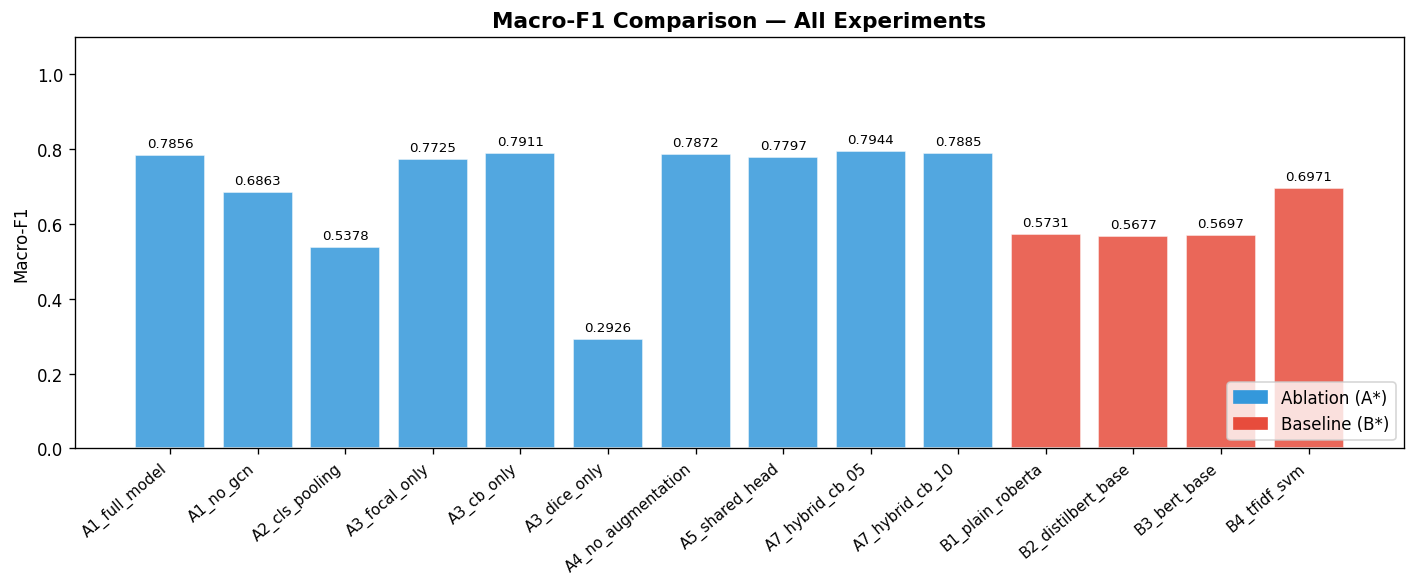

In [4]:
# Bar chart comparing Macro-F1 across all completed experiments.
# Blue bars = ablations (A*), Red bars = baselines (B*).
done   = df_results[df_results['Status'] == 'done']
colors = ['#3498db' if i.startswith('A') else '#e74c3c' for i in done.index]

fig, ax = plt.subplots(figsize=(max(10, len(done)*0.85), 5))
bars = ax.bar(done.index, done['Macro-F1'], color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)  # Show exact values on top of bars
ax.set_ylim(0, 1.1); ax.set_ylabel('Macro-F1')
ax.set_title('Macro-F1 Comparison — All Experiments', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Ablation (A*)'),
                   Patch(color='#e74c3c', label='Baseline (B*)')], loc='lower right')
plt.tight_layout(); plt.show()
